In [1]:
import pandas as pd
import numpy as np

data = {
    "고객ID": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "성별": ["남", "여", "여", "남", "여", "남", "남", "여", "남", "여"],
    "나이": [25, 32, 28, 41, 35, 22, 45, 30, 38, 27],
    "지역": ["서울", "부산", "서울", "대구", "인천", "서울", "부산", "대전", "서울", "인천"],
    "구매금액": [35000, 72000, 15000, 120000, 55000, 23000, 98000, 45000, 87000, 32000],
    "구매횟수": [2, 5, 1, 8, 4, 2, 6, 3, 5, 2],
    "회원등급": ["일반", "VIP", "일반", "VVIP", "VIP", "일반", "VIP", "일반", "VIP", "일반"],
    "만족도": [4, 5, 3, 5, 4, 2, 5, 4, 4, 3]
}

df = pd.DataFrame(data)

# 데이터 확인
df.head()       # 상위 5개 데이터
df.shape        # 행, 열 크기
df.columns      # 열 이름

Index(['고객ID', '성별', '나이', '지역', '구매금액', '구매횟수', '회원등급', '만족도'], dtype='str')

In [2]:
df.shape

(10, 8)

In [3]:
df.describe()

,고객ID,나이,구매금액,구매횟수,만족도
count,10.00000,10.000000,10.000000,10.00000,10.000000
mean,1005.50000,32.300000,58200.000000,3.80000,3.900000
std,3.02765,7.364328,34860.993802,2.20101,0.994429
min,1001.00000,22.000000,15000.000000,1.00000,2.000000
25%,1003.25000,27.250000,32750.000000,2.00000,3.250000
50%,1005.50000,31.000000,50000.000000,3.50000,4.000000
75%,1007.75000,37.250000,83250.000000,5.00000,4.750000
max,1010.00000,45.000000,120000.000000,8.00000,5.000000


In [4]:
df.groupby('성별')['구매금액'].mean()

성별
남    72600.0
여    43800.0
Name: 구매금액, dtype: float64

In [5]:
df['구매금액'].groupby(df['성별']).mean()

성별
남    72600.0
여    43800.0
Name: 구매금액, dtype: float64

In [6]:
df.groupby('성별')['구매금액'].mean()

성별
남    72600.0
여    43800.0
Name: 구매금액, dtype: float64

In [7]:
df.head()

,고객ID,성별,나이,지역,구매금액,구매횟수,회원등급,만족도
0,1001,남,25,서울,35000,2,일반,4
1,1002,여,32,부산,72000,5,VIP,5
2,1003,여,28,서울,15000,1,일반,3
3,1004,남,41,대구,120000,8,VVIP,5
4,1005,여,35,인천,55000,4,VIP,4


In [8]:
df['지역'].value_counts()

지역
서울    4
부산    2
인천    2
대구    1
대전    1
Name: count, dtype: int64

In [13]:
pd.crosstab(df['성별'], df['지역'])

지역,대구,대전,부산,서울,인천
성별,,,,,
남,1,0,1,3,0
여,0,1,1,1,2


In [14]:
pd.get_dummies(df)

,고객ID,나이,구매금액,구매횟수,만족도,성별_남,성별_여,지역_대구,지역_대전,지역_부산,지역_서울,지역_인천,회원등급_VIP,회원등급_VVIP,회원등급_일반
0,1001,25,35000,2,4,True,False,False,False,False,True,False,False,False,True
1,1002,32,72000,5,5,False,True,False,False,True,False,False,True,False,False
2,1003,28,15000,1,3,False,True,False,False,False,True,False,False,False,True
3,1004,41,120000,8,5,True,False,True,False,False,False,False,False,True,False
4,1005,35,55000,4,4,False,True,False,False,False,False,True,True,False,False
5,1006,22,23000,2,2,True,False,False,False,False,True,False,False,False,True
6,1007,45,98000,6,5,True,False,False,False,True,False,False,True,False,False
7,1008,30,45000,3,4,False,True,False,True,False,False,False,False,False,True
8,1009,38,87000,5,4,True,False,False,False,False,True,False,True,False,False
9,1010,27,32000,2,3,False,True,False,False,False,False,True,False,False,True


In [15]:
df.head()

,고객ID,성별,나이,지역,구매금액,구매횟수,회원등급,만족도
0,1001,남,25,서울,35000,2,일반,4
1,1002,여,32,부산,72000,5,VIP,5
2,1003,여,28,서울,15000,1,일반,3
3,1004,남,41,대구,120000,8,VVIP,5
4,1005,여,35,인천,55000,4,VIP,4


In [16]:
df['총액'] = df['구매금액'] * df['구매횟수']

In [20]:
df.drop(columns='총액', inplace=True)

In [21]:
df.head()

,고객ID,성별,나이,지역,구매금액,구매횟수,회원등급,만족도
0,1001,남,25,서울,35000,2,일반,4
1,1002,여,32,부산,72000,5,VIP,5
2,1003,여,28,서울,15000,1,일반,3
3,1004,남,41,대구,120000,8,VVIP,5
4,1005,여,35,인천,55000,4,VIP,4


In [23]:
df.isnull().sum()

고객ID    0
성별      0
나이      0
지역      0
구매금액    0
구매횟수    0
회원등급    0
만족도     0
dtype: int64

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   고객ID    10 non-null     int64
 1   성별      10 non-null     str  
 2   나이      10 non-null     int64
 3   지역      10 non-null     str  
 4   구매금액    10 non-null     int64
 5   구매횟수    10 non-null     int64
 6   회원등급    10 non-null     str  
 7   만족도     10 non-null     int64
dtypes: int64(5), str(3)
memory usage: 772.0 bytes


In [27]:
df.describe()

,고객ID,나이,구매금액,구매횟수,만족도
count,10.00000,10.000000,10.000000,10.00000,10.000000
mean,1005.50000,32.300000,58200.000000,3.80000,3.900000
std,3.02765,7.364328,34860.993802,2.20101,0.994429
min,1001.00000,22.000000,15000.000000,1.00000,2.000000
25%,1003.25000,27.250000,32750.000000,2.00000,3.250000
50%,1005.50000,31.000000,50000.000000,3.50000,4.000000
75%,1007.75000,37.250000,83250.000000,5.00000,4.750000
max,1010.00000,45.000000,120000.000000,8.00000,5.000000


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='나이', ylabel='Count'>

c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


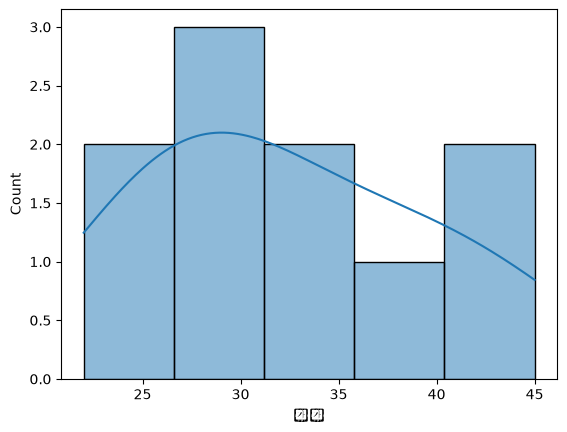

In [32]:
sns.histplot(df['나이'], kde=True)

<Axes: xlabel='구매횟수', ylabel='구매금액'>

c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 50529 (\N{

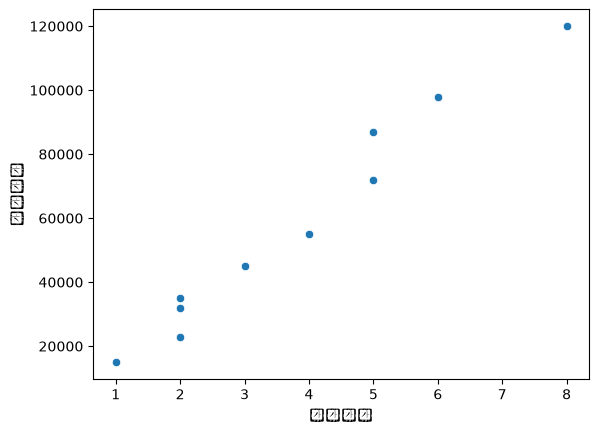

In [35]:
sns.scatterplot(x=df['구매횟수'], y=df['구매금액'])